In [1]:
import os
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set style for plots:
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Liberation Sans', 'DejaVu Sans'],
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'grid.color': '#eeeeee',
    'grid.linestyle': '--',
    'figure.titlesize': 14,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

In [ ]:
from pandas import plotting
from pandas import plotting
def run_day_1_eda():
    print("==================================================")
    print("PHASE A - DAY 1: NEPSE INDEX DATA LOAD & EDA")
    print("==================================================")
    
    # 1. Load Data from SQLite
    # Search multiple potential relative paths to locate the database robustly
    possible_paths = [
        os.path.join("..", "..", "Data", "Indexes.db"),  # Running from Research/notebooks/
        os.path.join("..", "Data", "Indexes.db"),        # Running from Research/
        os.path.join("Data", "Indexes.db")               # Running from root
    ]
    
    db_path = None
    for p in possible_paths:
        if os.path.exists(p):
            db_path = p
            break
            
    if db_path is None:
        raise FileNotFoundError(
            "Could not locate Data/Indexes.db. Ensure the Data folder exists in the project root."
        )
        
    print(f"Loading data from database: {db_path}")
    conn = sqlite3.connect(db_path)
    
    # Query raw NEPSE_Index data
    query = "SELECT * FROM NEPSE_Index;"
    df_raw = pd.read_sql_query(query, conn)
    conn.close()
    
    # 2. Initial Checks (Before Sorting)
    print("\n--- 1. Raw Dataset Properties (Initial Check) ---")
    print(f"DataFrame Shape: {df_raw.shape}")
    print("\nColumns and Data Types:")
    print(df_raw.dtypes)
    print("\nMissing values per column:")
    print(df_raw.isnull().sum())
    print("\nFirst 5 rows (as stored in DB):")
    print(df_raw.head())
    print("\nLast 5 rows (as stored in DB):")
    print(df_raw.tail())

    # 3. Date Parsing & Chronological Sorting
    print("\n--- 2. Date Parsing & Chronological Sorting ---")
    df = df_raw.copy()
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    
    # Sort ascending (earliest to latest)
    df = df.sort_values('trade_date').reset_index(drop=True)
    
    print("Sorted DataFrame First 5 rows (Chronological):")
    print(df.head())
    print("\nSorted DataFrame Last 5 rows (Chronological):")
    print(df.tail())
    
    # Check date spacing / consistency
    date_min = df['trade_date'].min()
    date_max = df['trade_date'].max()
    print(f"\nDate Range: From {date_min.strftime('%Y-%m-%d')} to {date_max.strftime('%Y-%m-%d')}")
    
    # Check for duplicate dates
    duplicate_dates = df['trade_date'].duplicated().sum()
    print(f"Duplicate trade dates: {duplicate_dates}")

    # 4. Statistical Summary
    print("\n--- 3. Descriptive Statistical Summary ---")
    stats = df[['index_value', 'absolute_change', 'percent_change', 'turnover']].describe()
    print(stats)
    
    # Calculate additional metrics for EDA discussion
    total_days = len(df)
    up_days = (df['percent_change'] > 0).sum()
    down_days = (df['percent_change'] < 0).sum()
    flat_days = (df['percent_change'] == 0).sum()
    
    print("\n--- 4. Market Dynamics ---")
    print(f"Total Trading Days: {total_days}")
    print(f"Up Days: {up_days} ({up_days/total_days*100:.2f}%)")
    print(f"Down Days: {down_days} ({down_days/total_days*100:.2f}%)")
    print(f"Flat Days: {flat_days} ({flat_days/total_days*100:.2f}%)")
    
    # 5. Visualization
    print("\n--- 5. Generating Visualizations ---")
    
    # Create output directory for figures inside Research folder if it doesn't exist
    #script_dir = os.path.dirname(os.path.abspath(__file__))
    #figures_dir = os.path.join(script_dir, "figures")
    #os.makedirs(figures_dir, exist_ok=True)

    
    # Plot 1: Closing Price and Turnover over Time
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Plot NEPSE Closing Price
    ax1.plot(df['trade_date'], df['index_value'], color='#1f77b4', linewidth=1.5, label='NEPSE Index Value')
    ax1.set_title('NEPSE Index Closing Price (Historical Overview)', fontsize=13, fontweight='bold', pad=10)
    ax1.set_ylabel('Index Value (Points)', fontweight='bold')
    ax1.legend(loc='upper left')
    
    # Plot Daily Turnover
    ax2.fill_between(df['trade_date'], df['turnover'], color='#2ca02c', alpha=0.3, label='Daily Turnover')
    ax2.plot(df['trade_date'], df['turnover'], color='#2ca02c', linewidth=0.5)
    ax2.set_title('NEPSE Daily Trading Turnover', fontsize=13, fontweight='bold', pad=10)
    ax2.set_ylabel('Turnover (NPR)', fontweight='bold')
    ax2.set_xlabel('Trade Date', fontweight='bold')
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    #plot_path_1 = os.path.join(figures_dir, "nepse_historical_overview.png")
    #plt.savefig(plot_path_1, dpi=150, bbox_inches='tight')
    #print(f"Saved: {plot_path_1}")
    #plt.close()
    plt.show()
    
    # Plot 2: Distribution of Daily Percent Changes (Volatility Clues)
    plt.figure(figsize=(10, 5))
    # Filter out extreme outliers for visualization purposes if necessary, or plot a KDE
    sns.histplot(df['percent_change'].dropna(), bins=100, kde=True, color='#8c564b', edgecolor='none')
    plt.title('Distribution of Daily Percentage Changes (Returns)', fontsize=13, fontweight='bold')
    plt.xlabel('Daily Return (%)')
    plt.ylabel('Frequency')
    plt.axvline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
    
    #plot_path_2 = os.path.join(figures_dir, "nepse_returns_distribution.png")
    #plt.savefig(plot_path_2, dpi=150, bbox_inches='tight')
    #print(f"Saved: {plot_path_2}")
    #plt.close()
    plt.show()
    return df

PHASE A - DAY 1: NEPSE INDEX DATA LOAD & EDA
Loading data from database: ..\..\Data\Indexes.db

--- 1. Raw Dataset Properties (Initial Check) ---
DataFrame Shape: (6033, 6)

Columns and Data Types:
sn                   int64
index_value        float64
absolute_change    float64
percent_change     float64
turnover           float64
trade_date             str
dtype: object

Missing values per column:
sn                 0
index_value        0
absolute_change    0
percent_change     0
turnover           0
trade_date         0
dtype: int64

First 5 rows (as stored in DB):
   sn  index_value  absolute_change  percent_change      turnover  trade_date
0   1      2798.83           -26.07           -0.92  1.197470e+10  2026-03-16
1   2      2824.90             4.45            0.15  1.432960e+10  2026-03-15
2   3      2820.44            23.87            0.85  1.455195e+10  2026-03-12
3   4      2796.57           -46.78           -1.64  1.318026e+10  2026-03-11
4   5      2843.35           -32.08 

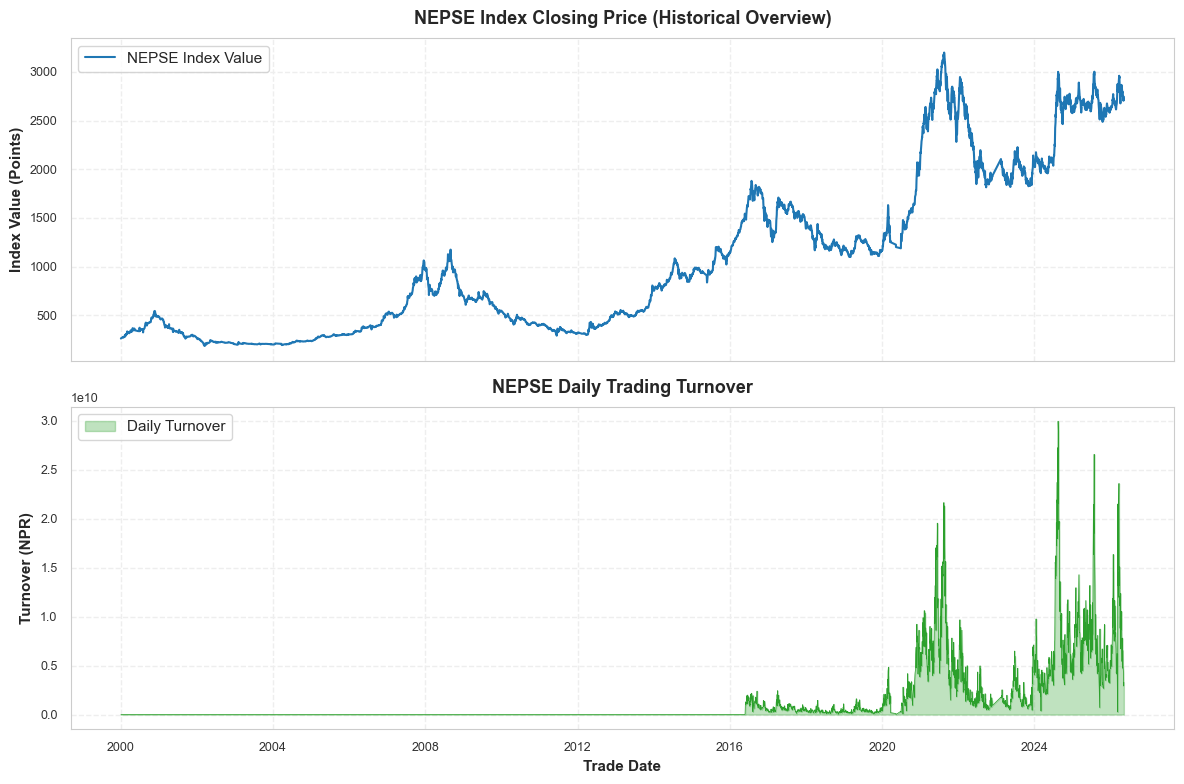

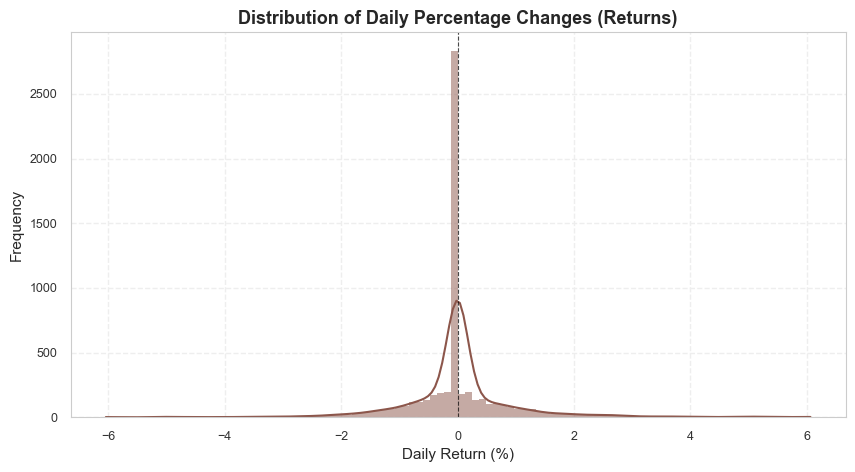


EDA Completed successfully!


: 

In [ ]:

if __name__ == "__main__":
    run_day_1_eda()
